# Online Shopper Purchase Intention Analysis and AI Prediction

**IBM SkillsBuild Data Analytics with AI Academic Internship Project**

### Project objective
Analyze online shopping-session behavior and build a machine-learning classification system that predicts whether a browsing session is likely to end in a purchase.

### Why this dataset?
This project uses the **Online Shoppers Purchasing Intention Dataset** from the UCI Machine Learning Repository. It is different from the sales dataset and house-price dataset mentioned as classroom examples. The dataset contains **12,330 online-shopping sessions**, 18 columns including the binary target `Revenue`, and supports classification/clustering tasks.

**Primary AI task:** Binary classification (`Revenue` = purchase / no purchase)  
**Analytics tasks:** data cleaning, exploratory data analysis, feature engineering, segmentation, correlation analysis and business insights.

**Dataset source:** https://archive.ics.uci.edu/dataset/468/online%2Bshoppers%2Bpurchasing%2Bintention%2Bdataset


In [1]:
# Install the required libraries if they are not already installed.
# In Jupyter/Colab, uncomment the next line when needed.
# %pip install -r requirements.txt


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)


In [3]:
# Load the official UCI dataset.
# The ucimlrepo method is the most robust option for this project.
try:
    from ucimlrepo import fetch_ucirepo

    dataset = fetch_ucirepo(id=468)
    X_raw = dataset.data.features.copy()
    y_raw = dataset.data.targets.copy()

    df = pd.concat([X_raw, y_raw], axis=1)
    print("Dataset loaded through UCI's ucimlrepo package.")
except Exception as e:
    print("ucimlrepo loading failed; trying the direct UCI CSV URL.")
    print("Reason:", e)

    DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
    df = pd.read_csv(DATA_URL)

print("Shape:", df.shape)
display(df.head())


Dataset loaded through UCI's ucimlrepo package.
Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
# Standardize a few data types and inspect the structure.
df.columns = [c.strip() for c in df.columns]

# The original dataset uses boolean values for Weekend and Revenue.
# Convert them to 0/1 for modeling.
for col in ["Weekend", "Revenue"]:
    if col in df.columns:
        if df[col].dtype == "bool":
            df[col] = df[col].astype(int)
        elif df[col].dtype == "object":
            df[col] = (
                df[col].astype(str).str.strip().str.lower()
                .map({"true": 1, "false": 0, "yes": 1, "no": 0})
            )

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Rows: 12330
Columns: 18

Data types:


,dtype
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [5]:
# Data quality checks
quality = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values("missing_values", ascending=False)

display(quality)
print("Duplicate rows:", df.duplicated().sum())


,missing_values,missing_percent,unique_values
Administrative,0,0.0,27
Administrative_Duration,0,0.0,3335
Informational,0,0.0,17
Informational_Duration,0,0.0,1258
ProductRelated,0,0.0,311
ProductRelated_Duration,0,0.0,9551
BounceRates,0,0.0,1872
ExitRates,0,0.0,4777
PageValues,0,0.0,2704
SpecialDay,0,0.0,6


Duplicate rows: 125


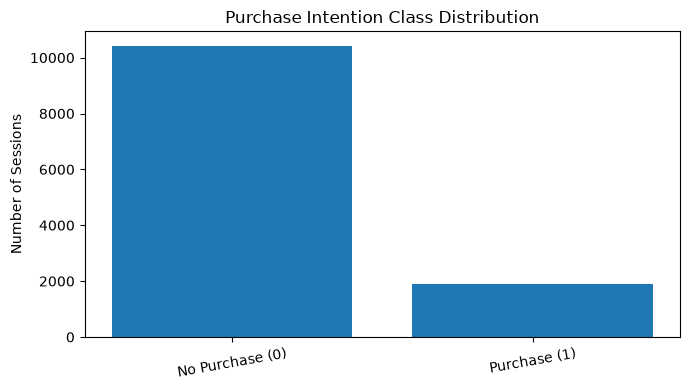

Target counts:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Purchase rate: 15.47%


In [6]:
# Target distribution
target_counts = df["Revenue"].value_counts().sort_index()
target_labels = ["No Purchase (0)", "Purchase (1)"]

plt.figure(figsize=(7, 4))
plt.bar(target_labels, [target_counts.get(0, 0), target_counts.get(1, 0)])
plt.title("Purchase Intention Class Distribution")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

print("Target counts:")
print(target_counts)
print("\nPurchase rate: {:.2f}%".format(df["Revenue"].mean() * 100))


In [7]:
# Numerical summary
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


,count,purchases,purchase_rate
VisitorType,,,
New_Visitor,1694,422,24.91
Other,85,16,18.82
Returning_Visitor,10551,1470,13.93


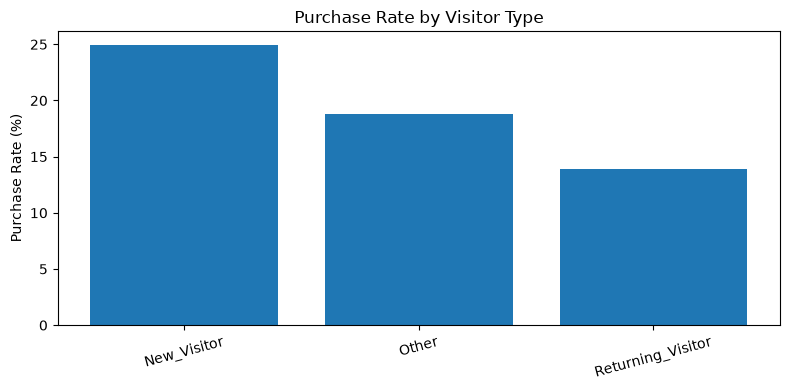

In [8]:
# Purchase rate by visitor type
visitor_summary = (
    df.groupby("VisitorType")["Revenue"]
      .agg(["count", "sum", "mean"])
      .rename(columns={"sum": "purchases", "mean": "purchase_rate"})
      .sort_values("purchase_rate", ascending=False)
)

visitor_summary["purchase_rate"] = (visitor_summary["purchase_rate"] * 100).round(2)
display(visitor_summary)

plt.figure(figsize=(8, 4))
plt.bar(visitor_summary.index.astype(str), visitor_summary["purchase_rate"])
plt.title("Purchase Rate by Visitor Type")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


,count,purchase_rate
Month,,
Feb,184,1.630435
Mar,1907,10.068170
May,3364,10.850178
June,288,10.069444
Jul,432,15.277778
Aug,433,17.551963
Sep,448,19.196429
Oct,549,20.947177
Nov,2998,25.350233


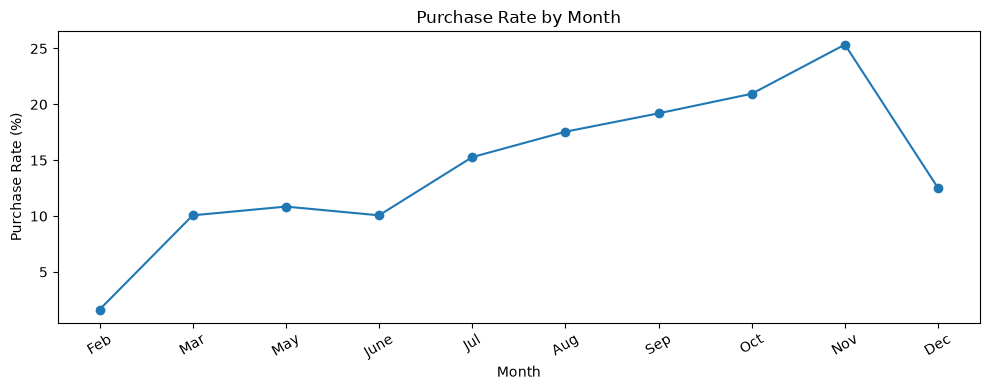

In [9]:
# Purchase rate by month
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly = df.groupby("Month")["Revenue"].agg(["count", "mean"]).copy()
monthly["purchase_rate"] = monthly["mean"] * 100
monthly["month_order"] = monthly.index.map({m: i for i, m in enumerate(month_order)})
monthly = monthly.sort_values("month_order")

display(monthly[["count", "purchase_rate"]])

plt.figure(figsize=(10, 4))
plt.plot(monthly.index, monthly["purchase_rate"], marker="o")
plt.title("Purchase Rate by Month")
plt.ylabel("Purchase Rate (%)")
plt.xlabel("Month")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


,No Purchase,Purchase
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
PageValues,1.975998,27.264518
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555


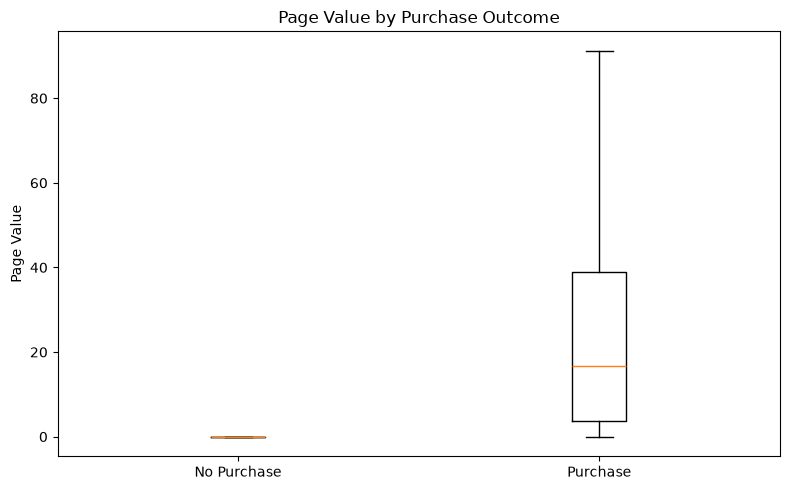

In [10]:
# Relationship between product-related page activity and purchase outcome
df["ProductRelated_TotalEngagement"] = (
    df["ProductRelated"] + df["ProductRelated_Duration"]
)

engagement_summary = (
    df.groupby("Revenue")[["ProductRelated", "ProductRelated_Duration", "PageValues",
                           "BounceRates", "ExitRates"]]
      .mean()
      .T
)
engagement_summary.columns = ["No Purchase", "Purchase"]
display(engagement_summary)

plt.figure(figsize=(8, 5))
plt.boxplot(
    [df.loc[df["Revenue"] == 0, "PageValues"],
     df.loc[df["Revenue"] == 1, "PageValues"]],
    tick_labels=["No Purchase", "Purchase"],
    showfliers=False
)
plt.title("Page Value by Purchase Outcome")
plt.ylabel("Page Value")
plt.tight_layout()
plt.show()


In [11]:
# Feature engineering
data = df.copy()

data["TotalPages"] = (
    data["Administrative"]
    + data["Informational"]
    + data["ProductRelated"]
)

data["TotalPageDuration"] = (
    data["Administrative_Duration"]
    + data["Informational_Duration"]
    + data["ProductRelated_Duration"]
)

data["AvgTimePerPage"] = np.where(
    data["TotalPages"] > 0,
    data["TotalPageDuration"] / data["TotalPages"],
    0
)

data["EngagementScore"] = (
    data["TotalPages"] * (1 + data["PageValues"])
    + data["TotalPageDuration"] / 60
)

# The target is separated before model training.
y = data["Revenue"].astype(int)
X = data.drop(columns=["Revenue"])

print("Engineered feature set shape:", X.shape)
display(X.head())


Engineered feature set shape: (12330, 22)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser,Region,TrafficType,VisitorType,Weekend,ProductRelated_TotalEngagement,TotalPages,TotalPageDuration,AvgTimePerPage,EngagementScore
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,1,1,Returning_Visitor,0,1.000000,1,0.000000,0.000000,1.000000
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,2,1,2,Returning_Visitor,0,66.000000,2,64.000000,32.000000,3.066667
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,9,3,Returning_Visitor,0,1.000000,1,0.000000,0.000000,1.000000
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,2,2,4,Returning_Visitor,0,4.666667,2,2.666667,1.333333,2.044444
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,3,1,4,Returning_Visitor,1,637.500000,10,627.500000,62.750000,20.458333


In [12]:
# Train-test split with stratification because the purchase class is smaller.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Categorical features:", categorical_features)
print("Numeric features:", len(numeric_features))


Training rows: 9864
Testing rows: 2466
Categorical features: ['Month', 'VisitorType']
Numeric features: 20


In [13]:
# Preprocessing pipeline.
# Numeric values are imputed/scaled; categorical values are imputed and one-hot encoded.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [14]:
# Two interpretable baseline/production-style models.
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=350,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
display(results_df.round(4))

results_df.to_csv(ARTIFACT_DIR / "model_comparison.csv", index=False)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.8954,0.6623,0.6623,0.6623,0.9240
1,Logistic Regression,0.8483,0.5070,0.7539,0.6063,0.8966


In [15]:
# Select the model using F1-score, which balances precision and recall.
selected_name = results_df.loc[0, "Model"]
selected_pipeline = fitted_pipelines[selected_name]

print("Selected model based on test-set F1-score:", selected_name)

selected_pred = selected_pipeline.predict(X_test)
selected_proba = selected_pipeline.predict_proba(X_test)[:, 1]

print("\nClassification report:")
print(classification_report(
    y_test,
    selected_pred,
    target_names=["No Purchase", "Purchase"],
    digits=4
))


Selected model based on test-set F1-score: Random Forest

Classification report:
              precision    recall  f1-score   support

 No Purchase     0.9381    0.9381    0.9381      2084
    Purchase     0.6623    0.6623    0.6623       382

    accuracy                         0.8954      2466
   macro avg     0.8002    0.8002    0.8002      2466
weighted avg     0.8954    0.8954    0.8954      2466



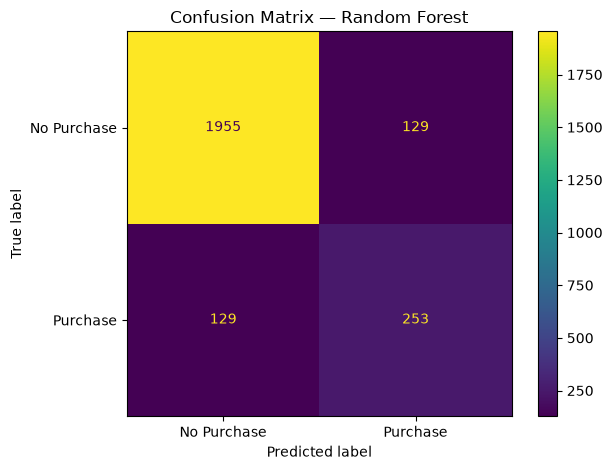

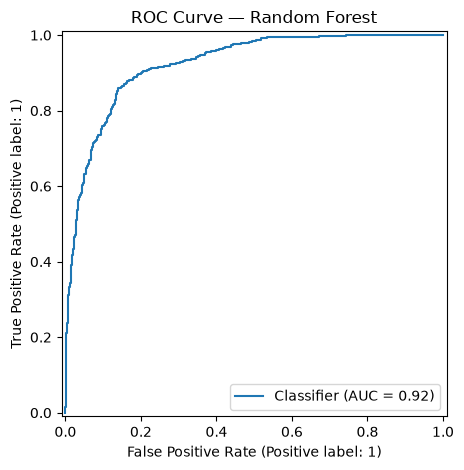

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, selected_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Purchase", "Purchase"]
)
disp.plot(values_format="d")
plt.title(f"Confusion Matrix — {selected_name}")
plt.tight_layout()
plt.show()

# ROC curve
RocCurveDisplay.from_predictions(y_test, selected_proba)
plt.title(f"ROC Curve — {selected_name}")
plt.tight_layout()
plt.show()


In [17]:
# Cross-validation on the training data.
# This gives a more stable estimate of model consistency.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}
for name, pipe in fitted_pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_scores[name] = scores
    print(f"{name}: mean F1 = {scores.mean():.4f}, std = {scores.std():.4f}")

cv_df = pd.DataFrame({
    "Model": list(cv_scores.keys()),
    "CV_F1_Mean": [v.mean() for v in cv_scores.values()],
    "CV_F1_Std": [v.std() for v in cv_scores.values()]
})
display(cv_df.round(4))
cv_df.to_csv(ARTIFACT_DIR / "cross_validation_f1.csv", index=False)


Logistic Regression: mean F1 = 0.6250, std = 0.0215
Random Forest: mean F1 = 0.6772, std = 0.0105


,Model,CV_F1_Mean,CV_F1_Std
0,Logistic Regression,0.6250,0.0215
1,Random Forest,0.6772,0.0105


,Feature,Importance_Mean,Importance_Std
0,PageValues,0.42880,0.01666
1,EngagementScore,0.09770,0.01205
2,ExitRates,0.03969,0.00932
3,Month,0.03346,0.00731
4,BounceRates,0.01173,0.00665
5,AvgTimePerPage,0.00686,0.00588
6,SpecialDay,0.00316,0.00184
7,OperatingSystems,0.00205,0.00225
8,ProductRelated_Duration,0.00180,0.00305
9,Browser,0.00107,0.00104


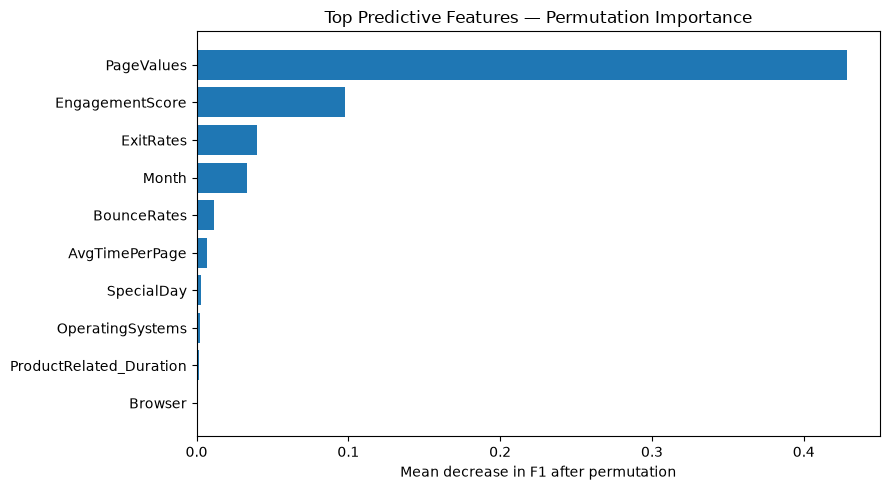

In [18]:
# Permutation importance on the held-out test set.
# This is model-agnostic and provides an interpretable view of which original
# input columns most affect predictive performance.
perm = permutation_importance(
    selected_pipeline,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance_Mean": perm.importances_mean,
        "Importance_Std": perm.importances_std
    })
    .sort_values("Importance_Mean", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(15).round(5))
importance_df.to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False)

top_n = 10
plot_df = importance_df.head(top_n).sort_values("Importance_Mean")

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Feature"], plot_df["Importance_Mean"])
plt.title("Top Predictive Features — Permutation Importance")
plt.xlabel("Mean decrease in F1 after permutation")
plt.tight_layout()
plt.show()


In [19]:
# Save the complete preprocessing + model pipeline.
model_path = ARTIFACT_DIR / "online_shopper_purchase_intention_model.joblib"
joblib.dump(selected_pipeline, model_path)

print("Saved model:", model_path)


Saved model: artifacts\online_shopper_purchase_intention_model.joblib


In [20]:
# Example inference on one test row.
# The model accepts the same raw feature columns used for training.
sample = X_test.iloc[[0]].copy()
sample_probability = selected_pipeline.predict_proba(sample)[0, 1]
sample_prediction = int(sample_probability >= 0.50)

print("Example prediction")
print("------------------")
print("Predicted class:", "Purchase" if sample_prediction else "No Purchase")
print("Purchase probability: {:.2%}".format(sample_probability))
display(sample)


Example prediction
------------------
Predicted class: No Purchase
Purchase probability: 1.10%


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser,Region,TrafficType,VisitorType,Weekend,ProductRelated_TotalEngagement,TotalPages,TotalPageDuration,AvgTimePerPage,EngagementScore
4722,1,4.0,0,0.0,13,161.166667,0.024615,0.061538,0.0,0.6,...,5,9,5,Returning_Visitor,0,174.166667,14,165.166667,11.797619,16.752778


In [21]:
def predict_purchase_intention(sample_session):

    # Convert dictionary to DataFrame
    new_data = pd.DataFrame([sample_session])

    # Create the same engineered features used by the model
    new_data["TotalPages"] = (
        new_data["Administrative"]
        + new_data["Informational"]
        + new_data["ProductRelated"]
    )

    new_data["ProductRelated_TotalEngagement"] = (
        new_data["ProductRelated"]
        + new_data["ProductRelated_Duration"]
    )

    new_data["TotalPageDuration"] = (
        new_data["Administrative_Duration"]
        + new_data["Informational_Duration"]
        + new_data["ProductRelated_Duration"]
    )

    new_data["AvgTimePerPage"] = (
        new_data["TotalPageDuration"]
        / new_data["TotalPages"].replace(0, 1)
    )

    new_data["EngagementScore"] = (
        new_data["PageValues"]
        + new_data["TotalPageDuration"]
    )

    # Apply preprocessing
    new_data_processed = preprocessor.transform(new_data)

    # Prediction
    probability = model.predict_proba(new_data_processed)[0, 1]

    prediction = "Purchase" if probability >= 0.50 else "No Purchase"

    return {
        "Prediction": prediction,
        "Purchase Probability": round(float(probability) * 100, 2)
    }

sample_session = {
    "Administrative": 2,
    "Administrative_Duration": 50.0,
    "Informational": 1,
    "Informational_Duration": 20.0,
    "ProductRelated": 20,
    "ProductRelated_Duration": 500.0,
    "BounceRates": 0.02,
    "ExitRates": 0.04,
    "PageValues": 20.0,
    "SpecialDay": 0.0,
    "Month": "Nov",
    "OperatingSystems": 2,
    "Browser": 1,
    "Region": 1,
    "TrafficType": 2,
    "VisitorType": "Returning_Visitor",
    "Weekend": False
}

result = predict_purchase_intention(sample_session)

print("Prediction:", result["Prediction"])
print("Purchase Probability:", result["Purchase Probability"], "%")

Prediction: Purchase
Purchase Probability: 57.07 %


In [22]:
# Automatically generate a concise project-results text file.
# This makes it easier to transfer the actual results into the final report.
best_row = results_df.iloc[0]

# PROJECT RESULTS SUMMARY

project_title = "Online Shopper Purchase Intention Analysis"

summary_text = f"""PROJECT RESULTS SUMMARY
========================

Project: {project_title}

Dataset rows: {len(df)}
Dataset columns: {len(df.columns)}

Purchase rate: {df["Revenue"].mean() * 100:.2f}%

Selected model: {selected_name}
Accuracy: {best_row["Accuracy"]:.4f}
Precision: {best_row["Precision"]:.4f}
Recall: {best_row["Recall"]:.4f}
F1-score: {best_row["F1"]:.4f}
ROC-AUC: {best_row["ROC_AUC"]:.4f}

The notebook also generated:
- artifacts/model_comparison.csv
- artifacts/cross_validation_f1.csv
- artifacts/feature_importance.csv
- artifacts/online_shopper_purchase_intention_model.joblib
"""

# Save summary
results_summary_path = ARTIFACT_DIR / "results_summary.txt"
results_summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("\nResults summary saved successfully.")

PROJECT RESULTS SUMMARY

Project: Online Shopper Purchase Intention Analysis

Dataset rows: 12330
Dataset columns: 19

Purchase rate: 15.47%

Selected model: Random Forest
Accuracy: 0.8954
Precision: 0.6623
Recall: 0.6623
F1-score: 0.6623
ROC-AUC: 0.9240

The notebook also generated:
- artifacts/model_comparison.csv
- artifacts/cross_validation_f1.csv
- artifacts/feature_importance.csv
- artifacts/online_shopper_purchase_intention_model.joblib


Results summary saved successfully.


## Final interpretation

The project combines descriptive analytics with supervised machine learning. The analytics section identifies browsing and visitor characteristics associated with purchase outcomes, while the AI section converts those patterns into a binary prediction model.

The notebook intentionally computes all final model metrics instead of hard-coding results. This avoids presenting fabricated performance figures. Run all cells once after installing the requirements and downloading the official dataset connection; the generated `artifacts/results_summary.txt` contains the exact values to use in the report.

### Submission checklist
- [ ] Run all notebook cells successfully.
- [ ] Confirm the final metrics are visible.
- [ ] Confirm the `artifacts` folder was generated if your evaluator permits supporting files.
- [ ] Keep the required four submission files together.
- [ ] Replace `Student` in filenames with your actual name if required by the internship portal.
